In [1]:
!pip install datasets tensorflow scikit-learn

In [2]:
import numpy as np
import pandas as pd
from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

from sklearn.metrics import classification_report, accuracy_score

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from datasets import load_dataset
import pandas as pd

# Load dataset
dataset = load_dataset("sh0416/ag_news")

# Convert to DataFrame
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

# Save as CSV
train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Dataset saved successfully!")

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DELL\.cache\huggingface\hub\datasets--sh0416--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 433331.21 examples/s]


Dataset saved successfully!


In [ ]:
dataset = load_dataset("sh0416/ag_news")

train_data = dataset["train"]
test_data = dataset["test"]

X_train = [title + " " + description for title, description in zip(train_data["title"], train_data["description"])]
y_train = np.array(train_data["label"]) - 1 # Adjust labels to be 0-indexed

X_test = [title + " " + description for title, description in zip(test_data["title"], test_data["description"])]
y_test = np.array(test_data["label"]) - 1 # Adjust labels to be 0-indexed

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120000
Testing Samples: 7600


In [6]:
print(train_data.column_names)

['label', 'title', 'description']


In [7]:
vocab_size = 10000
max_length = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [8]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

In [9]:
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

model.summary()

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    X_train_pad,
    np.array(y_train),
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.6450 - loss: 0.9023 - val_accuracy: 0.7440 - val_loss: 0.7572
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.6319 - loss: 0.9681 - val_accuracy: 0.6053 - val_loss: 1.0121
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.7076 - loss: 0.8305 - val_accuracy: 0.6453 - val_loss: 1.0079
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.7232 - loss: 0.7939 - val_accuracy: 0.6795 - val_loss: 0.8871
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.7366 - loss: 0.7496 - val_accuracy: 0.6760 - val_loss: 0.8960


In [12]:
loss, accuracy = model.evaluate(
    X_test_pad,
    np.array(y_test) # Labels are already 0-indexed (0, 1, 2, 3) from hQh6YOYH_AFz
)

print("Test Accuracy:", accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6803 - loss: 0.8785
Test Accuracy: 0.6802631616592407


In [13]:
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=[
        "World",
        "Sports",
        "Business",
        "Sci/Tech"
    ]
))

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
              precision    recall  f1-score   support

       World       0.68      0.70      0.69      1900
      Sports       0.71      0.80      0.76      1900
    Business       0.72      0.55      0.63      1900
    Sci/Tech       0.62      0.67      0.64      1900

    accuracy                           0.68      7600
   macro avg       0.68      0.68      0.68      7600
weighted avg       0.68      0.68      0.68      7600



In [14]:
sample_news = [
    "India won the cricket series against Australia.",
    "Stock market gains after positive economic reports.",
    "Scientists develop a new AI-powered healthcare system."
]

sample_seq = tokenizer.texts_to_sequences(sample_news)


In [15]:
sample_pad = pad_sequences(
    sample_seq,
    maxlen=max_length,
    padding='post'
)

predictions = model.predict(sample_pad)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [16]:
categories = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

for news, pred in zip(sample_news, predictions):
    print(news)
    print("Category:", categories[np.argmax(pred)])
    print()

India won the cricket series against Australia.
Category: World

Stock market gains after positive economic reports.
Category: Business

Scientists develop a new AI-powered healthcare system.
Category: Sci/Tech



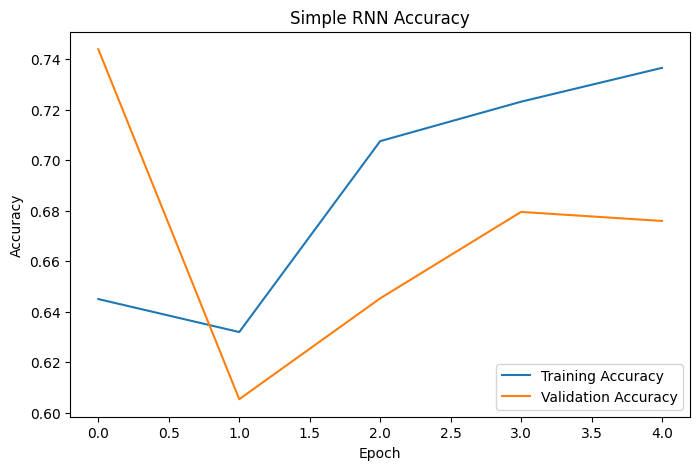

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Simple RNN Accuracy")
plt.legend()
plt.show()